In [15]:
import pandas as pd
import numpy as np

amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
clim_path = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

amr = pd.read_csv(amr_path)
clim = pd.read_csv(clim_path)

amr.head(), clim.head()


(  Province  Year  MRCNS  VREFS  VREFM  PRSP  ERSP  3GCRKP  MRSA  3GCREC  CREC  \
 0       北京  2014   82.2    1.6   11.1   0.4  97.0    39.0  49.0    58.8   3.6   
 1       天津  2014   79.6    0.3    1.9   9.3  96.2    21.5  24.8    51.4   1.5   
 2       河北  2014   80.3    0.7    2.4   7.0  97.4    47.5  43.4    66.3   2.2   
 3       山西  2014   70.5    0.6    1.3   1.4  93.8    31.7  24.2    58.4   1.2   
 4      内蒙古  2014   76.3    0.7    1.4   9.1  95.8    26.1  28.9    55.6   0.6   
 
    QREC  CRPA  CRKP  CRAB  
 0  61.3  36.1  13.7  64.0  
 1  51.0  22.1   1.7  22.1  
 2  60.1  30.9   6.7  63.0  
 3  55.5  20.4   2.6  52.7  
 4  65.4  20.2   1.9  51.5  ,
     省份  YEAR  主要城市平均气温  主要城市降水量  主要城市日照时数      省平均气温       省平均降水    TA（°C）  \
 0   北京  2014      14.1    461.5    2344.1  11.802834  459.925228  0.649418   
 1   天津  2014      14.0    441.4    2265.6  13.439358  445.971354  0.668522   
 2   河北  2014      14.9    294.8    1585.4  10.775661  439.600300  0.622596   
 3   山西  2014  

In [16]:
amr.columns = [c.strip() for c in amr.columns]
clim.columns = [c.strip() for c in clim.columns]

# 统一键名
amr = amr.rename(columns={"Province":"省份", "Year":"YEAR"})
clim = clim.rename(columns={"省份":"省份", "YEAR":"YEAR"})


In [17]:
amr["YEAR"] = pd.to_numeric(amr["YEAR"], errors="coerce")
clim["YEAR"] = pd.to_numeric(clim["YEAR"], errors="coerce")

amr["省份"] = amr["省份"].astype(str).str.strip()
clim["省份"] = clim["省份"].astype(str).str.strip()

for c in amr.columns:
    if c not in ["省份","YEAR"]:
        amr[c] = pd.to_numeric(amr[c], errors="coerce")

for c in clim.columns:
    if c not in ["省份","YEAR"]:
        clim[c] = pd.to_numeric(clim[c], errors="coerce")


In [18]:
panel = pd.merge(amr, clim, on=["省份","YEAR"], how="inner")

panel.shape, panel.head()


((310, 47),
     省份  YEAR  MRCNS  VREFS  VREFM  PRSP  ERSP  3GCRKP  MRSA  3GCREC  ...  \
 0   北京  2014   82.2    1.6   11.1   0.4  97.0    39.0  49.0    58.8  ...   
 1   天津  2014   79.6    0.3    1.9   9.3  96.2    21.5  24.8    51.4  ...   
 2   河北  2014   80.3    0.7    2.4   7.0  97.4    47.5  43.4    66.3  ...   
 3   山西  2014   70.5    0.6    1.3   1.4  93.8    31.7  24.2    58.4  ...   
 4  内蒙古  2014   76.3    0.7    1.4   9.1  95.8    26.1  28.9    55.6  ...   
 
    人均日生活用水量(升)  牲畜饲养\n-大牲畜年底头数  牲畜饲养\n-猪年底头数  牲畜饲养\n-羊年底头数  Unnamed: 28  \
 0       187.52           20.32        179.60         68.35          NaN   
 1       124.33           30.38        199.78         46.76          NaN   
 2       116.91          488.23       1915.45       1526.40          NaN   
 3       114.59          123.87        514.74        922.74          NaN   
 4       103.49          839.86        669.44       5569.28          NaN   
 
    Unnamed: 29    文盲程度  森林火灾受害面积  Unnamed: 32  Unnamed: 33  
 0  

In [19]:
amr_cols = [
    "MRSA","CRKP","CRAB","CRPA","CREC",
    "3GCREC","3GCRKP","QREC",
    "MRCNS","VREFS","VREFM","PRSP","ERSP"
]

amr_cols = [c for c in amr_cols if c in panel.columns]
amr_cols


['MRSA',
 'CRKP',
 'CRAB',
 'CRPA',
 'CREC',
 '3GCREC',
 '3GCRKP',
 'QREC',
 'MRCNS',
 'VREFS',
 'VREFM',
 'PRSP',
 'ERSP']

In [20]:
climate_vars = ["TA（°C）","PA（%）","R1xday","R5xday"]

climate_vars = [c for c in climate_vars if c in panel.columns]
climate_vars


['TA（°C）', 'PA（%）', 'R1xday', 'R5xday']

In [21]:
panel2 = panel.sort_values(["省份","YEAR"]).copy()

for col in amr_cols + climate_vars:
    panel2[col] = panel2.groupby("省份")[col].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )
    panel2[col] = panel2.groupby("省份")[col].transform(
        lambda s: s.fillna(s.median())
    )
    panel2[col] = panel2[col].fillna(panel2[col].median())


d:\anaconda3\envs\iodide\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\iodide\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


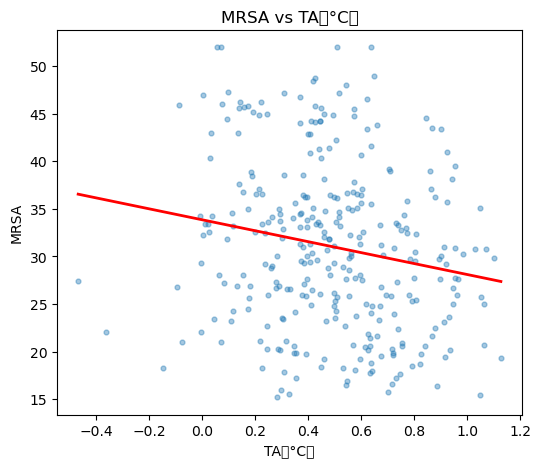

In [22]:
import matplotlib.pyplot as plt

x = "TA（°C）"
y = "MRSA"

plt.figure(figsize=(6,5))
plt.scatter(panel2[x], panel2[y], s=12, alpha=0.4)

coef = np.polyfit(panel2[x], panel2[y], 1)
xs = np.linspace(panel2[x].min(), panel2[x].max(), 100)
ys = coef[0]*xs + coef[1]
plt.plot(xs, ys, color="red", lw=2)

plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{y} vs {x}")
plt.show()


In [ ]:
for y in amr_cols:
    plt.figure(figsize=(5,4))
    plt.scatter(panel2[x], panel2[y], s=10, alpha=0.3)
    coef = np.polyfit(panel2[x], panel2[y], 1)
    xs = np.linspace(panel2[x].min(), panel2[x].max(), 80)
    ys = coef[0]*xs + coef[1]
    plt.plot(xs, ys, color="black", lw=2)
    plt.title(f"{y} vs {x}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()


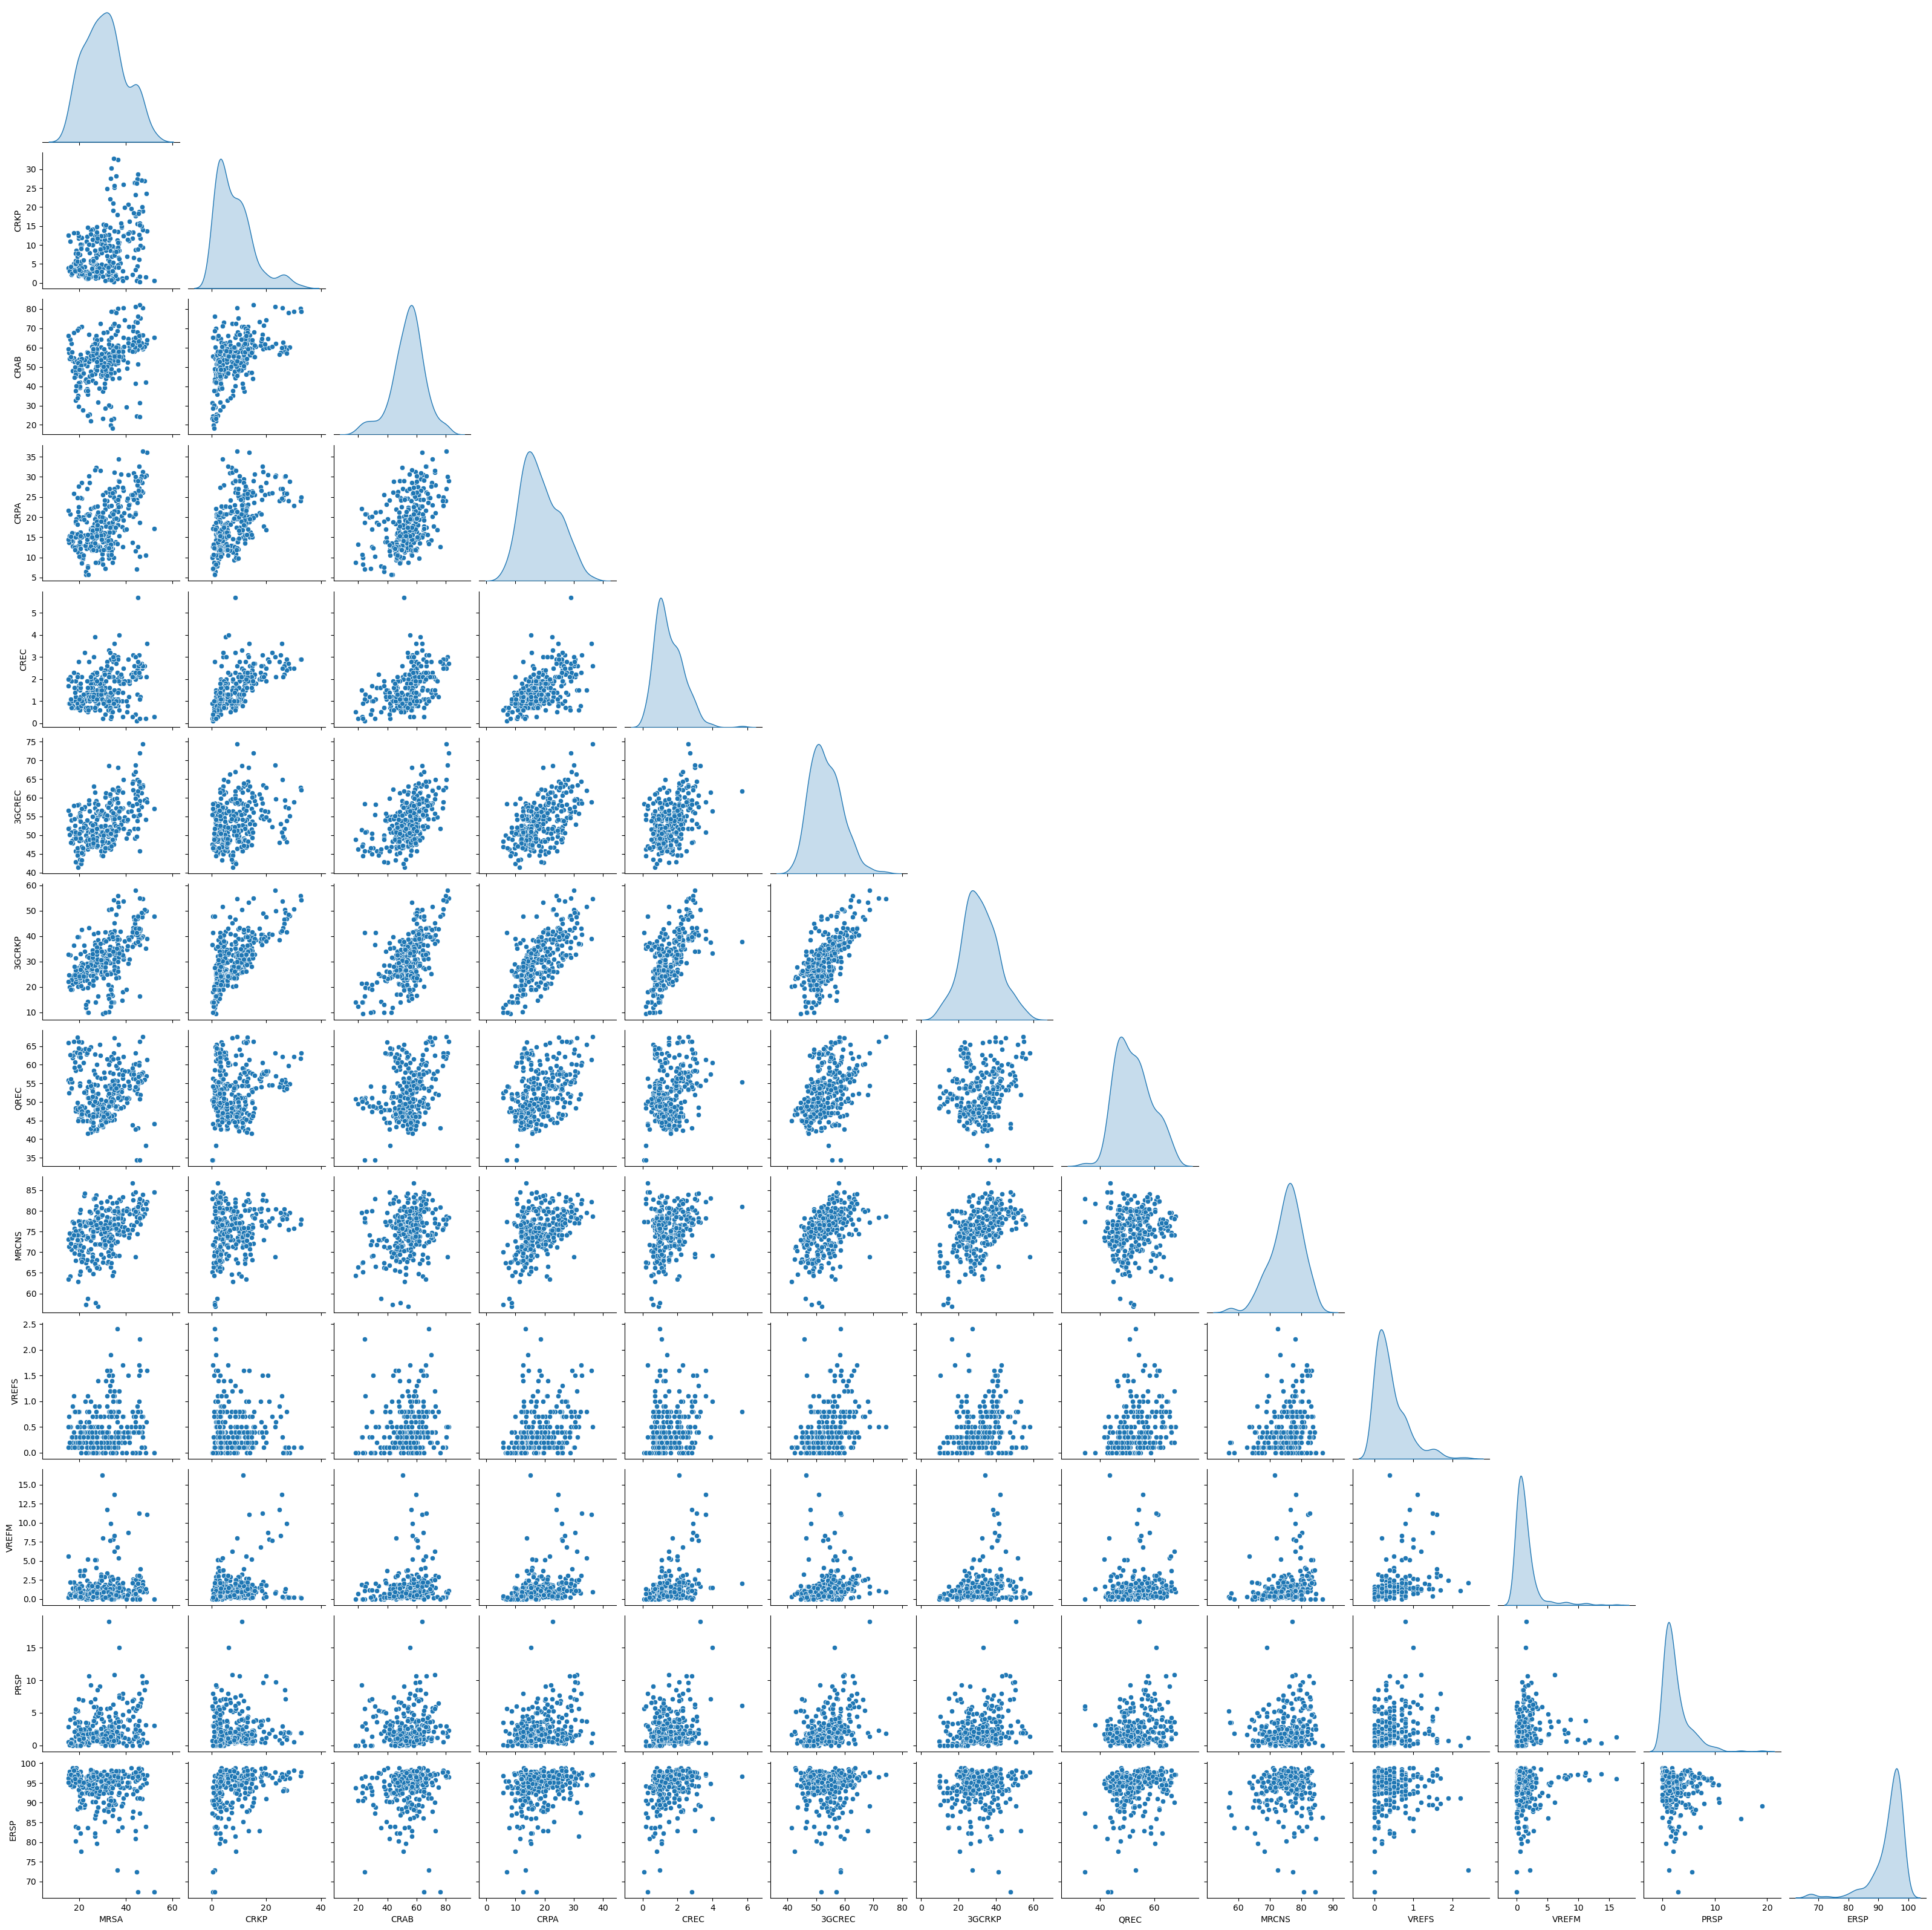

In [26]:
import seaborn as sns

# vars_for_pair = climate_vars + amr_cols[:4]   # 先放4个AMR避免太拥挤
# vars_for_pair = climate_vars + amr_cols
vars_for_pair = amr_cols
sns.pairplot(panel2[vars_for_pair], diag_kind="kde", corner=True)
plt.show()
